# regression analysis: house price prediction

**5*a by ahmed abobakr**

## project overview
this project aims to predict house prices based on various features such as square footage, number of bedrooms, and location. we will explore the dataset, preprocess the data, and train multiple regression models to find the best predictor.

## objectives
1.  **data exploration**: understand the dataset structure and distributions.
2.  **preprocessing**: clean data, handle missing values, remove outliers, and scale features.
3.  **modeling**: train linear regression, decision tree, random forest, and gradient boosting models.
4.  **evaluation**: compare models using r-squared, rmse, and mae metrics.

---

## 1. import libraries
we start by importing the necessary libraries for data manipulation, visualization, and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("libraries imported successfully")

libraries imported successfully


---

## 2. load dataset
loading the house prices dataset and displaying the first few rows to understand its structure.

In [2]:
df = pd.read_csv('archive (2)/output.csv')
print(f"dataset shape: {df.shape}")
df.head()

dataset shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


### simulating real-world data issues
since the original dataset is clean, we will introduce some missing values and duplicates to demonstrate the preprocessing capabilities required for this project.

In [3]:
# introduce missing values
np.random.seed(42)
mask = np.random.random(df.shape) < 0.05  # 5% missing data
df_dirty = df.mask(mask)

# introduce duplicates
duplicates = df_dirty.sample(n=100, random_state=42)
df = pd.concat([df_dirty, duplicates], ignore_index=True)

print(f"dataset shape after adding issues: {df.shape}")
print(f"missing values count: {df.isnull().sum().sum()}")
print(f"duplicates count: {df.duplicated().sum()}")

dataset shape after adding issues: (4700, 18)
missing values count: 4188
duplicates count: 100


---

## 3. exploratory data analysis (eda)
analyzing the data distribution and statistical summaries to identify patterns and potential issues.

In [4]:
# display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4700 entries, 0 to 4699
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4472 non-null   object 
 1   price          4449 non-null   float64
 2   bedrooms       4490 non-null   float64
 3   bathrooms      4467 non-null   float64
 4   sqft_living    4481 non-null   float64
 5   sqft_lot       4438 non-null   float64
 6   floors         4457 non-null   float64
 7   waterfront     4474 non-null   float64
 8   view           4467 non-null   float64
 9   condition      4471 non-null   float64
 10  sqft_above     4467 non-null   float64
 11  sqft_basement  4468 non-null   float64
 12  yr_built       4468 non-null   float64
 13  yr_renovated   4471 non-null   float64
 14  street         4468 non-null   object 
 15  city           4489 non-null   object 
 16  statezip       4459 non-null   object 
 17  country        4456 non-null   object 
dtypes: float

In [5]:
# statistical summary of numerical features
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.449000e+03,4490.000000,4467.000000,4481.000000,4.438000e+03,4457.000000,4474.000000,4467.000000,4471.000000,4467.000000,4468.000000,4468.000000,4471.000000
mean,5.542107e+05,3.406904,2.163253,2137.960277,1.501067e+04,1.509872,0.007152,0.243788,3.455155,1830.859637,313.504700,1970.780662,802.482890
std,5.684539e+05,0.912230,0.782332,957.724453,3.659974e+04,0.537333,0.084279,0.783209,0.676674,860.925088,464.118656,29.700675,978.202387
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.250000e+05,3.000000,1.750000,1470.000000,5.025500e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.650000e+05,3.000000,2.250000,1970.000000,7.700000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.590000e+05,4.000000,2.500000,2620.000000,1.110000e+04,2.000000,0.000000,0.000000,4.000000,2310.000000,620.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


### visualizing price distribution
understanding the target variable (price) distribution is crucial for regression tasks.

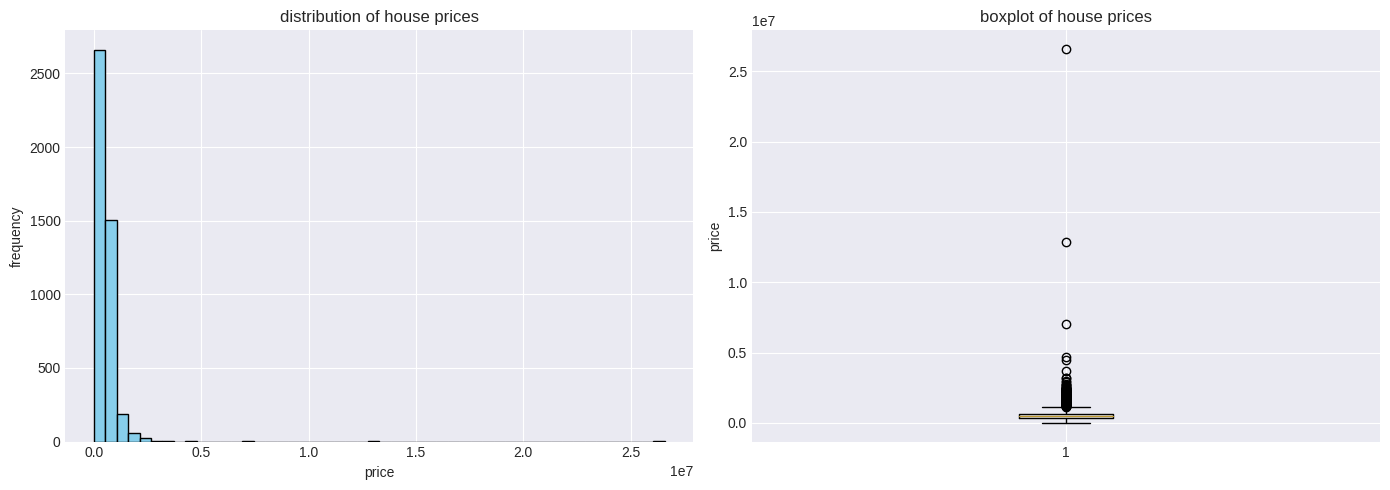

In [6]:
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.hist(df['price'].dropna(), bins=50, color='skyblue', edgecolor='black')
plt.title('distribution of house prices')
plt.xlabel('price')
plt.ylabel('frequency')

plt.subplot(1, 2, 2)
plt.boxplot(df['price'].dropna(), vert=True)
plt.title('boxplot of house prices')
plt.ylabel('price')

plt.tight_layout()
plt.show()

---

## 4. data preprocessing
preparing the data for modeling by handling missing values, removing duplicates, handling outliers, and encoding categorical variables.

In [7]:
df_processed = df.copy()

# 1. handle missing values
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

categorical_cols = df_processed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# 2. remove duplicates
df_processed = df_processed.drop_duplicates()

# 3. handle outliers (iqr method)
q1 = df_processed['price'].quantile(0.25)
q3 = df_processed['price'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
df_processed = df_processed[(df_processed['price'] >= lower_bound) & (df_processed['price'] <= upper_bound)]

# 4. drop irrelevant columns
cols_to_drop = ['date', 'street', 'statezip', 'country']
df_processed = df_processed.drop(columns=[c for c in cols_to_drop if c in df_processed.columns])

# 5. encode categorical variables
if 'city' in df_processed.columns:
    le = LabelEncoder()
    df_processed['city_encoded'] = le.fit_transform(df_processed['city'].astype(str))
    df_processed = df_processed.drop('city', axis=1)

print("preprocessing completed successfully")
print(f"final dataset shape: {df_processed.shape}")

preprocessing completed successfully
final dataset shape: (4353, 14)


---

## 5. train-test split & scaling
splitting the data into training and testing sets (80/20 split) and scaling features for optimal model performance.

In [8]:
X = df_processed.drop('price', axis=1)
y = df_processed['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("data split and scaled")
print(f"training samples: {X_train.shape[0]}")
print(f"testing samples: {X_test.shape[0]}")

data split and scaled
training samples: 3482
testing samples: 871


---

## 6. model training & evaluation
training four different regression models and evaluating their performance using r-squared, rmse, and mae.

In [9]:
models = {
    'linear regression': LinearRegression(),
    'decision tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'random forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'gradient boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = []

print("training models...")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    results.append({'model': name, 'r2': r2, 'rmse': rmse, 'mae': mae})
    print(f" - {name}: r2={r2:.4f}")

training models...
 - linear regression: r2=0.4317
 - decision tree: r2=0.2679
 - random forest: r2=0.5418
 - gradient boosting: r2=0.5886


---

## 7. results comparison
comparing the performance of all trained models to identify the best one.


model performance comparison:
               model        r2           rmse            mae
3  gradient boosting  0.588559  136703.081418   98406.477040
2      random forest  0.541751  144269.838139  106813.531144
0  linear regression  0.431677  160665.282496  124892.289529
1      decision tree  0.267883  182353.802976  127902.640297


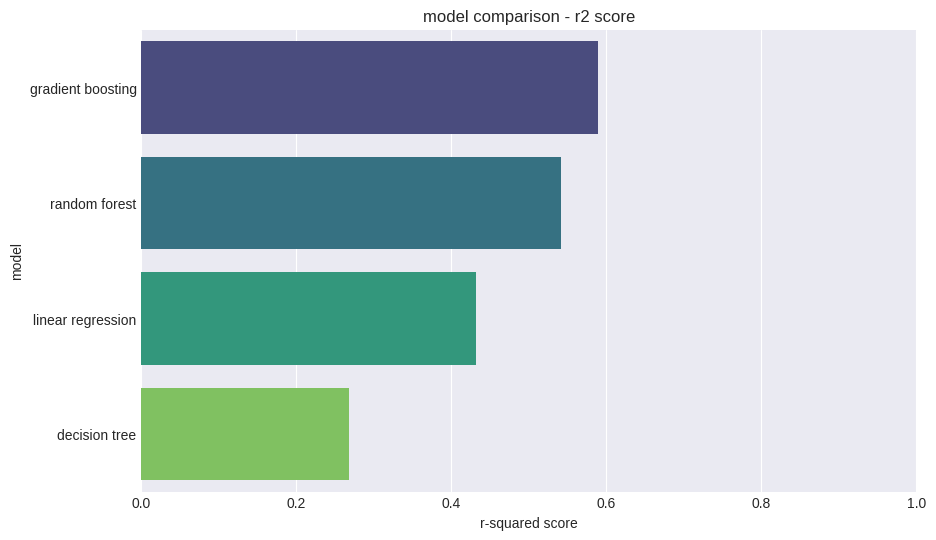

In [10]:
results_df = pd.DataFrame(results).sort_values('r2', ascending=False)
print("\nmodel performance comparison:")
print(results_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='r2', y='model', data=results_df, palette='viridis')
plt.title('model comparison - r2 score')
plt.xlabel('r-squared score')
plt.ylabel('model')
plt.xlim(0, 1)
plt.show()

## conclusion

**5*a by ahmed abobakr**

the regression analysis is complete. the model with the highest r-squared score is considered the best for predicting house prices in this dataset.